# Deep Learning Baseline for SCANIA Predictive Maintenance

### Project Overview
This notebook implements a **Deep Learning Baseline (LSTM)** for the SCANIA Component X dataset. The purpose is to benchmark the performance of the interpretable XGBoost model (implemented in `Code.ipynb`) against a standard "Black Box" neural network designed for time-series data.

**This is not the main model. Primary models are ML models, this is just a reference model.**

### Methodology
The following steps are being followed:

1.  **Data Loading:** Load the same dataset as the main notebook.
2.  **Preprocessing:** Use the same decumulation logic but **preserve the time sequence** (do not aggregate).
3.  **Padding:** Pad sequences to a fixed length since trucks have different history lengths.
4.  **Modeling:** Train a simple LSTM (Long Short-Term Memory) network using PyTorch/TensorFlow.
5.  **Evaluation:** Compare Recall and F1-Score with the XGBoost model.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, roc_auc_score, roc_curve, confusion_matrix
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using the device: {device}")

Using the device: mps


In [2]:
# Set the SEED value for reproducibility
SEED = 42
import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. Data Loading and Preprocessing

In [3]:
DATASET_DIR_PATH = "SCANIA Dataset/data/"

# Load Training Data
train_operational_readout_DF = pd.read_csv(DATASET_DIR_PATH + "train_operational_readouts.csv")
train_labels_DF = pd.read_csv(DATASET_DIR_PATH + "train_tte.csv")

In [4]:
# Load Test Data
test_operational_readout_DF = pd.read_csv(DATASET_DIR_PATH + "test_operational_readouts.csv")
test_labels_DF = pd.read_csv(DATASET_DIR_PATH + "test_labels.csv")

In [5]:
validation_operational_readout_DF = pd.read_csv(DATASET_DIR_PATH + "validation_operational_readouts.csv")
validation_labels = pd.read_csv(DATASET_DIR_PATH + "validation_labels.csv")

In [6]:
print(f"Train Operational Readout DataFrame Shape: {train_operational_readout_DF.shape}")
print(f"Test Operational Readout DataFrame Shape: {test_operational_readout_DF.shape}")

Train Operational Readout DataFrame Shape: (1122452, 107)
Test Operational Readout DataFrame Shape: (198140, 107)


In [7]:
def preprocess_sequences(df):
    """
    This function preprocesses one operational readout dataframe into per-step delta sequences.
    It follows the same strategy as the ML notebook (Code.ipynb).
    """
    df = df.sort_values(by=['vehicle_id', 'time_step']).reset_index(drop=True)
    sensor_columns = [c for c in df.columns if c not in ['vehicle_id', 'time_step']]

    # Apply missingness indicators
    missing_indicator_columns = []
    for column_name in sensor_columns:
        if df[column_name].isnull().any():
            df[f'{column_name}_is_missing'] = df[column_name].isnull().astype(int)
            missing_indicator_columns.append(f'{column_name}_is_missing')

    # Apply forward-fill within each vehicle
    df[sensor_columns] = df.groupby('vehicle_id')[sensor_columns].ffill()

    # Fill remaining NULLs (no prior value) with 0
    df[sensor_columns] = df[sensor_columns].fillna(0)

    # Decumulate
    df_diff = df.groupby('vehicle_id')[sensor_columns].diff()

    # Fill first-row NULL with 0
    df_diff = df_diff.fillna(0).clip(lower=0)

    df_final = pd.concat(
        [df[['vehicle_id', 'time_step'] + missing_indicator_columns].reset_index(drop=True),
         df_diff.reset_index(drop=True)],
        axis=1
    )
    return df_final, sensor_columns

In [8]:
# Preprocess the train sequences
train_operational_readout_DF_seq, feature_column_names = preprocess_sequences(train_operational_readout_DF)

# Let's see the shape of the FDataFrame after preprocessing
print(f"Shape of the Operational Readout DataFrame after preprocessing: {train_operational_readout_DF_seq.shape}")
print(f"Total number of fature columns: {len(feature_column_names)}")

Shape of the Operational Readout DataFrame after preprocessing: (1122452, 211)
Total number of fature columns: 105


In [9]:
# Preprocess the test sequences
test_operational_readout_DF_seq, _ = preprocess_sequences(test_operational_readout_DF)

# Preprocessing Validation sequences
validation_seq, _ = preprocess_sequences(validation_operational_readout_DF)

## 2. Time-Series Inputs and Aggregate Features

LSTMs expect input of shape `(Batch_Size, Sequence_Length, Num_Features)`. Since the sensor records do not have the same length/testing period, we cap each vehicle's sequence at `MAX_SEQ_LEN=100` recent steps.

LSTMs require input in the form `(batch_size, sequence_length, num_features)`. Because sensor records vary in length, each vehicle’s sequence is limited to the most recent `MAX_SEQ_LEN = 100` time steps.

By cutting the data, we are solving the variable length issue but creating a new problem that the modle is not getting the full history of the individual vehicle. So, to address this issues, we compute additional scalar features for each vehicle. These features summarize lifetime behavior rather than just recent activity:
	•	`total_usage` per sensor: the sum of all recorded changes, representing total accumulated wear
	•	`num_time_steps`: the total number of observations for the vehicle

In [10]:
# Cap to last MAX_SEQ_LEN steps per vehicle. Increased from 50 to capture more
# recent temporal context — matches the ML notebook's long_window=10 + short_window=5
# plus additional recent history the aggregations summarise.
MAX_SEQ_LEN = 100

def create_dataset(seq_DF, labels_DF, feature_columns, max_length):
    """
    This function combines the individual truck's sequence of readings and ensures that their length is fixed at 
    `MAX_SEQ_LEN`, either by clipping or padding. 
    """
    sequences = [] # Placeholder to store all the sequential data of individual truck
    labels = [] # Placeholder to store the corresponding label values
    # Get vehicle IDs
    vehicle_ids = labels_DF['vehicle_id'].unique()

    for vehicle_id_x in vehicle_ids:
        individual_truck_data = seq_DF[seq_DF['vehicle_id'] == vehicle_id_x][feature_columns].values
        if len(individual_truck_data) >= max_length:
            seq = individual_truck_data[-max_length:]
        else:
            pad_len = max_length - len(individual_truck_data)
            seq = np.pad(individual_truck_data, ((pad_len, 0), (0, 0)), mode='constant')
        sequences.append(seq)

        if 'in_study_repair' in labels_DF.columns:
            label = int(labels_DF[labels_DF['vehicle_id'] == vehicle_id_x]['in_study_repair'].values[0])
        else:
            raw = labels_DF[labels_DF['vehicle_id'] == vehicle_id_x]['class_label'].values[0]
            label = int(raw > 0)
        labels.append(label)

    return np.array(sequences, dtype=np.float32), np.array(labels, dtype=np.float32)

In [11]:
def compute_aggregate_features(seq_DF, labels_DF, feature_columns):
    """
    This function calculates the aggregate statistics for the whole life of a truck.
    """
    aggregate_list = []
    vehicle_ids = labels_DF['vehicle_id'].unique()

    for vehicle_id_x in vehicle_ids:
        truck_data = seq_DF[seq_DF['vehicle_id'] == vehicle_id_x][feature_columns].values
        total_usage = truck_data.sum(axis=0)
        num_steps = np.array([len(truck_data)], dtype=np.float32)
        aggregate_list.append(np.concatenate([total_usage, num_steps]))

    return np.array(aggregate_list, dtype=np.float32)


In [12]:
# Create sequence tensors
X_train_raw, y_train = create_dataset(train_operational_readout_DF_seq,train_labels_DF,feature_column_names, MAX_SEQ_LEN)
X_test_raw,y_test  = create_dataset(test_operational_readout_DF_seq,test_labels_DF,feature_column_names,MAX_SEQ_LEN)
X_validation_raw, y_validation = create_dataset(validation_seq,validation_labels,feature_column_names, MAX_SEQ_LEN)

In [13]:
# Let's check the number of failures
print(f"Shape of train dataset: {X_train_raw.shape} and total number of failures={int(y_train.sum())} ({round(y_train.mean()*100,1)}%)")
print(f"Shape of the test: {X_test_raw.shape} and total number of failures={int(y_test.sum())} ({round(y_test.mean()*100,1)}%)")
print(f"Shape of validation dataset: {X_validation_raw.shape} and the total failures={int(y_validation.sum())} ({round(y_validation.mean()*100,1)}%)")

Shape of train dataset: (23550, 100, 105) and total number of failures=2272 (9.6%)
Shape of the test: (5045, 100, 105) and total number of failures=142 (2.8%)
Shape of validation dataset: (5046, 100, 105) and the total failures=136 (2.7%)


In [14]:
# Now, let's compute the aggregate features
X_train_aggregate_raw = compute_aggregate_features(train_operational_readout_DF_seq,train_labels_DF,feature_column_names)
X_test_aggregate_raw  = compute_aggregate_features(test_operational_readout_DF_seq,test_labels_DF,feature_column_names)
X_validation_aggregate_raw = compute_aggregate_features(validation_seq, validation_labels,feature_column_names)
print(f"Aggregate features shape for the training dataste: {X_train_aggregate_raw.shape}")

Aggregate features shape for the training dataste: (23550, 106)


In [15]:
# Normalise sequence features (fit on train only)
sequence_scaler = StandardScaler()
n_features  = X_train_raw.shape[2]
X_train_raw_scaled = sequence_scaler.fit_transform(X_train_raw.reshape(-1, n_features)).reshape(X_train_raw.shape)
X_test_raw_scaled  = sequence_scaler.transform(X_test_raw.reshape(-1, n_features)).reshape(X_test_raw.shape)
X_validation_raw_scaled   = sequence_scaler.transform(X_validation_raw.reshape(-1, n_features)).reshape(X_validation_raw.shape)

In [16]:
# Normalise the aggregate features (fit on train dataset only)
aggregate_scaler = StandardScaler()
X_train_aggregate_raw_scaled = aggregate_scaler.fit_transform(X_train_aggregate_raw)
X_test_aggregate_raw_scaled  = aggregate_scaler.transform(X_test_aggregate_raw)
X_validation_aggregate_raw_scaled = aggregate_scaler.transform(X_validation_aggregate_raw)

In [17]:
# Check the final shapes of the datsets
print(f"Sequence train dataset shape: {X_train_raw_scaled.shape}")
print(f"Aggregate train dataset shape: {X_train_aggregate_raw_scaled.shape}")

Sequence train dataset shape: (23550, 100, 105)
Aggregate train dataset shape: (23550, 106)


## 3. Imbalance Handling

To address class imbalance in the time series data, we use `WeightedRandomSampler`. Rather than creating synthetic sequences using SMOTE, it simply draws minority-class sequences more frequently during training.

We train two models for comparison:
- **Model 1 — Baseline**: It is trained on the original imbalanced data using `BCEWithLogitsLoss(pos_weight)`, and gives more importance to failure cases.
- **Model 2 — Balanced**: It is trained with `WeightedRandomSampler`. In this method, each batch contains a more balanced mix of failure and non-failure samples.

In [18]:
from torch.utils.data import WeightedRandomSampler

class_counts = np.bincount(y_train.astype(int))   # [n_healthy, n_failures]
class_weights = 1.0 / class_counts                 # [w_healthy, w_failure]
sample_weights = torch.DoubleTensor(
    class_weights[y_train.astype(int)]
)

print(f"Class counts: healthy={class_counts[0]}  failure={class_counts[1]}")
print(f"Sample weights: healthy={round(class_weights[0],6)}  failure={round(class_weights[1],5)}")
print(f"Upsampling ratio (failure / healthy weight): {round(class_weights[1]/class_weights[0],1)}x")

Class counts: healthy=21278  failure=2272
Sample weights: healthy=4.7e-05  failure=0.00044
Upsampling ratio (failure / healthy weight): 9.4x


## 4. LSTM Model Definition

In [19]:
class LSTMPredictor(nn.Module):
    def __init__(self, input_dimensions, hidden_dimmensions, number_of_layers, aggregation_dimensions):
        super().__init__()
        self.lstm = nn.LSTM(input_dimensions, hidden_dimmensions, number_of_layers,
                            batch_first=True, dropout=0.3)
        # Project LSTM + aggregate features to output
        self.fc = nn.Sequential(
            nn.Linear(hidden_dimmensions + aggregation_dimensions, hidden_dimmensions),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dimmensions, 1),
        )

    def forward(self, x_sequence, x_aggregate):
        out, _ = self.lstm(x_sequence)
        last_hidden = out[:, -1, :] # (batch, hidden_dim)
        combined = torch.cat([last_hidden, x_aggregate], dim=1)    # (batch, hidden+agg)
        return self.fc(combined).squeeze(1) # (batch,)

In [20]:
# Set the hyperparameters
INPUT_DIM = X_train_raw_scaled.shape[2]
AGGREGATE_DIM = X_train_aggregate_raw_scaled.shape[1]
HIDDEN_DIM = 128
NUM_LAYERS = 2
BATCH_SIZE = 64
LR = 5e-4
EPOCHS = 40

pos_weight_val = float((y_train == 0).sum()) / float((y_train == 1).sum())
print(f"pos_weight is '{round(pos_weight_val,2)}'")

pw_tensor = torch.tensor([pos_weight_val], dtype=torch.float32).to(device)


pos_weight is '9.37'


In [21]:
# Model 1 --> baseline with pos_weight loss
model_baseline  = LSTMPredictor(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, AGGREGATE_DIM).to(device)
criterion_base  = nn.BCEWithLogitsLoss(pos_weight=pw_tensor)
optimizer_base  = optim.Adam(model_baseline.parameters(), lr=LR)

# Model 2 —-> Balanced sampling (WeightedRandomSampler)
model_balanced = LSTMPredictor(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, AGGREGATE_DIM).to(device)
criterion_balanced = nn.BCEWithLogitsLoss()
optimizer_balanced = optim.Adam(model_balanced.parameters(), lr=LR)

In [22]:
print(f"Input dimensions = {INPUT_DIM}")
print(f"Aggregate dimensions = {AGGREGATE_DIM}")
print(f"Hidden dimensions = {HIDDEN_DIM}")
print(f"Total number of LSTM layers = {NUM_LAYERS}")
print(f"Total number of trainable parameters: {sum(p.numel() for p in model_baseline.parameters())}")

Input dimensions = 105
Aggregate dimensions = 106
Hidden dimensions = 128
Total number of LSTM layers = 2
Total number of trainable parameters: 282625


## 5. Training Loop

In [23]:
def train_model(model, optimizer, criterion, X_train_input, X_train_aggregate_input, y_train_input,
                X_validation_input, X_validation_aggregate_input, y_validation_input,
                sample_weights=None, epochs=EPOCHS, patience=7):

    torch.manual_seed(SEED)

    train_dataset = TensorDataset(
        torch.tensor(X_train_input,dtype=torch.float32),
        torch.tensor(X_train_aggregate_input,dtype=torch.float32),
        torch.tensor(y_train_input,dtype=torch.float32),
    )

    if sample_weights is not None:
        sampler = WeightedRandomSampler(
            weights=sample_weights, num_samples=len(sample_weights), replacement=True
        )
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
    else:
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    X_validation_tensor = torch.tensor(X_validation_input,dtype=torch.float32).to(device)
    X_validation_aggregate_tensor = torch.tensor(X_validation_aggregate_input,dtype=torch.float32).to(device)
    y_validation_tensor = torch.tensor(y_validation_input,dtype=torch.float32).to(device)

    train_losses = []
    val_losses = []
    best_val_loss  = float('inf')
    best_state     = None
    patience_count = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for X_seq, X_agg, y_batch in train_loader:
            X_seq, X_agg, y_batch = X_seq.to(device), X_agg.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_seq, X_agg)
            loss = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss = epoch_loss + loss.item()

        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_validation_tensor, X_validation_aggregate_tensor)
            val_loss = criterion(val_logits, y_validation_tensor).item()
        val_losses.append(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}]  "
                  f"Train Loss: {round(avg_train_loss,4)}  |  Val Loss: {round(val_loss,4)}")

        # Early stopping
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"Early stopping at epoch {epoch+1}  (best val loss: {round(best_val_loss,4)})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return train_losses, val_losses



In [24]:
# Train the first model
print("Training Model 1 —-> Baseline LSTM (pos_weight loss, shuffled batches)")
loss_train_base, loss_validation_base = train_model(
    model_baseline, optimizer_base, criterion_base,
    X_train_raw_scaled, X_train_aggregate_raw_scaled, y_train,
    X_validation_raw_scaled, X_validation_aggregate_raw_scaled, y_validation,
    sample_weights=None,
)

Training Model 1 —-> Baseline LSTM (pos_weight loss, shuffled batches)
Epoch [5/40]  Train Loss: 0.9706  |  Val Loss: 0.7522
Epoch [10/40]  Train Loss: 0.7668  |  Val Loss: 0.8859
Early stopping at epoch 12  (best val loss: 0.7522)


In [25]:
print("Training Model 2 —-> Balanced LSTM (standard loss, WeightedRandomSampler)")
loss_train_balanced, loss_validation_balanced = train_model(
    model_balanced, optimizer_balanced, criterion_balanced,
    X_train_raw_scaled, X_train_aggregate_raw_scaled, y_train,
    X_validation_raw_scaled, X_validation_aggregate_raw_scaled, y_validation,
    sample_weights=sample_weights,
)

Training Model 2 —-> Balanced LSTM (standard loss, WeightedRandomSampler)
Epoch [5/40]  Train Loss: 0.3747  |  Val Loss: 0.5169
Epoch [10/40]  Train Loss: 0.1855  |  Val Loss: 0.4021
Early stopping at epoch 14  (best val loss: 0.3654)


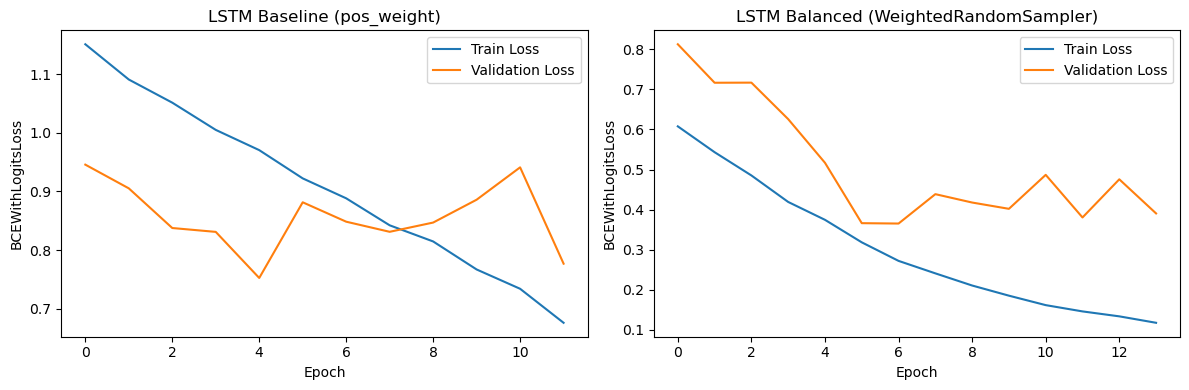

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_train_base, label='Train Loss')
axes[0].plot(loss_validation_base, label='Validation Loss')
axes[0].set_title('LSTM Baseline (pos_weight)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCEWithLogitsLoss')
axes[0].legend()

axes[1].plot(loss_train_balanced, label='Train Loss')
axes[1].plot(loss_validation_balanced, label='Validation Loss')
axes[1].set_title('LSTM Balanced (WeightedRandomSampler)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('BCEWithLogitsLoss')
axes[1].legend()

plt.tight_layout()
plt.savefig('Plots/dl_learning_curves.png', dpi=1200, bbox_inches='tight')
plt.show()

## 6. Comparison Evaluation

In [27]:
from sklearn.metrics import precision_recall_curve, fbeta_score

def evaluate_model(model, model_name, X_sequence, X_aggregate, y_true, threshold=None):
    # Get predicted probabilities from the model
    model.eval()
    with torch.no_grad():
        sequence_tensor  = torch.tensor(X_sequence,  dtype=torch.float32).to(device)
        aggregate_tensor = torch.tensor(X_aggregate, dtype=torch.float32).to(device)
        logits  = model(sequence_tensor, aggregate_tensor).cpu().numpy()
        y_probability = torch.sigmoid(torch.tensor(logits)).numpy()

    if threshold is None: # find the best F2 threshold using the validation set
        _, _, threshold_values = precision_recall_curve(y_true, y_probability)
        best_thr = 0.5
        best_f2  = 0.0
        for thr in threshold_values:
            y_pred_tmp = (y_probability >= thr).astype(int)
            f2 = fbeta_score(y_true, y_pred_tmp, beta=2, zero_division=0)
            if f2 > best_f2:
                best_f2 = f2
                best_thr = thr
        threshold = best_thr

    y_pred = (y_probability >= threshold).astype(int)
    recall = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_probability)

    print(f"{model_name}")
    print(classification_report(y_true, y_pred, target_names=['Healthy (0)', 'Failure (1)'], zero_division=0))
    print(f"Threshold : {round(threshold,4)}")
    print(f"Recall    : {round(recall,4)}")
    print(f"Precision : {round(precision,4)}")
    print(f"F1        : {round(f1,4)}")
    print(f"ROC-AUC   : {round(roc_auc,4)}")

    return {
        'Recall': recall, 'Precision': precision, 'F1': f1, 'ROC-AUC': roc_auc,
        'threshold': threshold, 'y_probability': y_probability, 'y_pred': y_pred
    }

# First, find the optimal threshold using the validation set
# This avoids test-set peeking when selecting the decision boundary
print("Finding optimal F2 threshold on the validation set.")
validation_results_baseline = evaluate_model(model_baseline, "LSTM Baseline — Validation",
                                             X_validation_raw_scaled, X_validation_aggregate_raw_scaled, y_validation)
validation_results_balanced = evaluate_model(model_balanced, "LSTM Balanced — Validation",
                                             X_validation_raw_scaled, X_validation_aggregate_raw_scaled, y_validation)

Finding optimal F2 threshold on the validation set.
LSTM Baseline — Validation
              precision    recall  f1-score   support

 Healthy (0)       0.98      0.82      0.89      4910
 Failure (1)       0.06      0.45      0.11       136

    accuracy                           0.81      5046
   macro avg       0.52      0.63      0.50      5046
weighted avg       0.96      0.81      0.87      5046

Threshold : 0.597599983215332
Recall    : 0.4485
Precision : 0.0638
F1        : 0.1117
ROC-AUC   : 0.6964
LSTM Balanced — Validation
              precision    recall  f1-score   support

 Healthy (0)       0.98      0.74      0.85      4910
 Failure (1)       0.05      0.45      0.08       136

    accuracy                           0.74      5046
   macro avg       0.51      0.60      0.46      5046
weighted avg       0.95      0.74      0.82      5046

Threshold : 0.2712000012397766
Recall    : 0.4485
Precision : 0.0461
F1        : 0.0836
ROC-AUC   : 0.6235


In [28]:
# Now evaluate both models on the test set using the thresholds found above
print("Evaluating both models on the test set.")

test_results_baseline = evaluate_model(
    model_baseline, "LSTM Baseline (pos_weight loss)",
    X_test_raw_scaled, X_test_aggregate_raw_scaled, y_test,
    threshold=validation_results_baseline['threshold']
)
test_results_balanced = evaluate_model(
    model_balanced, "LSTM Balanced (WeightedRandomSampler)",
    X_test_raw_scaled, X_test_aggregate_raw_scaled, y_test,
    threshold=validation_results_balanced['threshold']
)

# Print a side-by-side summary table
metrics = ['Recall', 'Precision', 'F1', 'ROC-AUC']
summary_table = pd.DataFrame({
    'LSTM Baseline (pos_weight)' : {m: test_results_baseline[m] for m in metrics},
    'LSTM Balanced (WRS)'        : {m: test_results_balanced[m]  for m in metrics},
}).T

print("\nFinal DL Model Performance Summary:")
print(summary_table.to_string())

Evaluating both models on the test set.
LSTM Baseline (pos_weight loss)
              precision    recall  f1-score   support

 Healthy (0)       0.98      0.81      0.89      4903
 Failure (1)       0.05      0.37      0.09       142

    accuracy                           0.80      5045
   macro avg       0.52      0.59      0.49      5045
weighted avg       0.95      0.80      0.86      5045

Threshold : 0.597599983215332
Recall    : 0.3732
Precision : 0.0536
F1        : 0.0937
ROC-AUC   : 0.6506
LSTM Balanced (WeightedRandomSampler)
              precision    recall  f1-score   support

 Healthy (0)       0.97      0.82      0.89      4903
 Failure (1)       0.04      0.27      0.07       142

    accuracy                           0.80      5045
   macro avg       0.51      0.54      0.48      5045
weighted avg       0.95      0.80      0.87      5045

Threshold : 0.2712000012397766
Recall    : 0.2676
Precision : 0.0406
F1        : 0.0705
ROC-AUC   : 0.5613

Final DL Model Perform

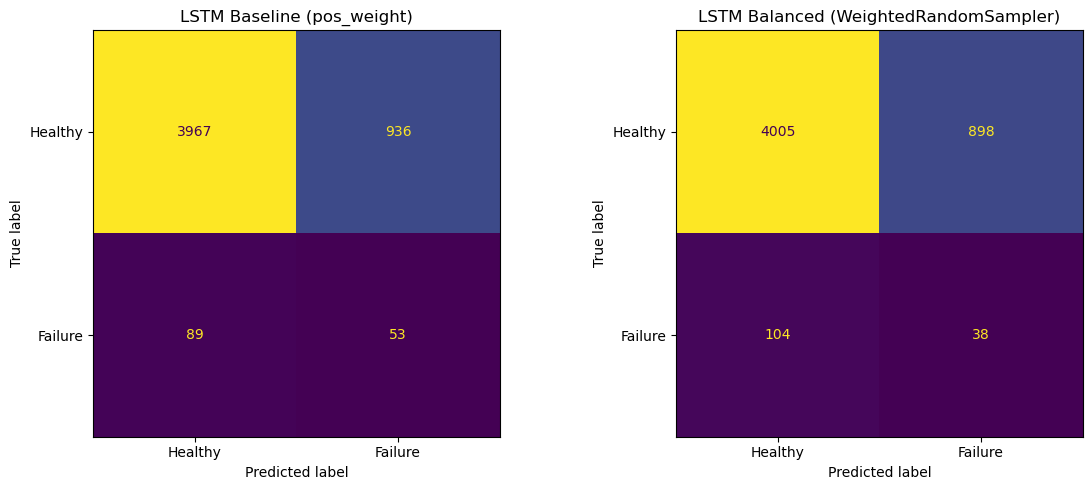

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, test_results_baseline['y_pred'],
    display_labels=['Healthy', 'Failure'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('LSTM Baseline (pos_weight)')

ConfusionMatrixDisplay.from_predictions(
    y_test, test_results_balanced['y_pred'],
    display_labels=['Healthy', 'Failure'],
    ax=axes[1], colorbar=False
)
axes[1].set_title('LSTM Balanced (WeightedRandomSampler)')

plt.tight_layout()
plt.savefig('Plots/dl_confusion_matrices.png', dpi=1200, bbox_inches='tight')
plt.show()

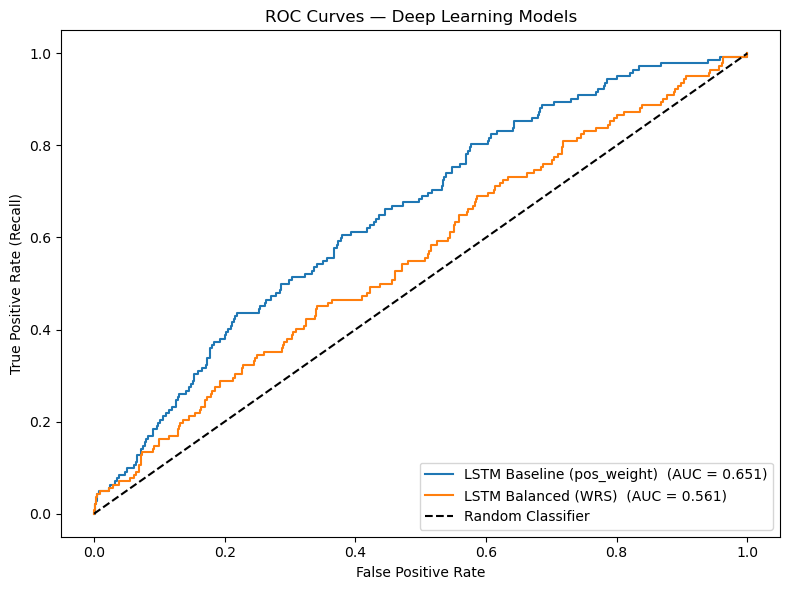

In [30]:
fpr_base, tpr_base, _ = roc_curve(y_test, test_results_baseline['y_probability'])
fpr_bal,  tpr_bal,  _ = roc_curve(y_test, test_results_balanced['y_probability'])

plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, label=f'LSTM Baseline (pos_weight)  (AUC = {round(test_results_baseline["ROC-AUC"],3)})')
plt.plot(fpr_bal,  tpr_bal,  label=f'LSTM Balanced (WRS)  (AUC = {round(test_results_balanced["ROC-AUC"],3)})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — Deep Learning Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('Plots/dl_roc_curves.png', dpi=1200, bbox_inches='tight')
plt.show()